# Pretrain Sequence Encoder for PBMC

This tutorial demonstrates how to pretrain a sequence encoder for predicting chromatin accessibility from DNA sequences using Peripheral Blood Mononuclear Cells (PBMC) data. This approach creates a foundational model that can be used for downstream Cell2Net applications across immune cell types.

In [20]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from scipy import stats
import torch
import cell2net as cn
import mudata as md
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

md.set_options(pull_on_update=False)

## Load PBMC Multiome Data

Import the preprocessed PBMC multiome dataset containing paired RNA-seq and ATAC-seq measurements from the same cells. This dataset represents the cellular diversity of the immune system. You can downloaded the Mudata object [here]().

In [21]:
mdata = md.read_h5mu("./mdata.h5mu")

Load and examine the MuData object structure:

In [22]:
mdata

MuData object with n_obs × n_vars = 11131 × 131516
  obs:	'cell_type', 'cell_type_v2', 'total_counts_rna', 'total_counts_atac', 'total_counts_rna_log', 'total_counts_atac_log'
  2 modalities
    rna:	11131 x 15932
      obs:	'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'cell_type_v2'
      var:	'genes', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'cell_type_colors', 'cell_type_v2_colors', 'hvg'
      obsm:	'X_umap'
      layers:	'counts'
    atac:	11131 x 115584
      obs:	'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'cell_type_v2'
      var:	'peaks', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      uns:	'cell_type_colors', 'cell_type_v2_colors'
      obsm:	'X_umap'
      layers:	'counts'

## Visualize PBMC Cell Type Diversity

Explore the cellular composition and quality of our PBMC dataset using UMAP visualizations. This helps us understand the immune cell populations present and their transcriptional and epigenetic relationships.

### RNA Expression Landscape

Visualize the transcriptional diversity across PBMC cell types. Each point represents a single cell, colored by its annotated cell type.

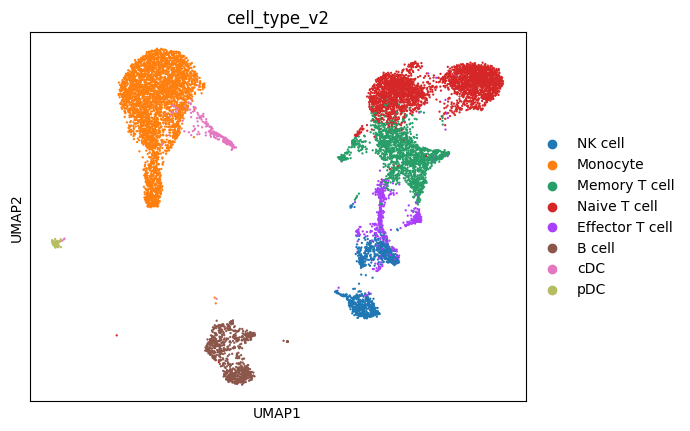

In [23]:
sc.pl.umap(mdata["rna"], color="cell_type_v2")

### Chromatin Accessibility Landscape  

Examine the epigenetic diversity across the same PBMC cell types. The ATAC-seq data reveals cell-type-specific regulatory elements and chromatin states.

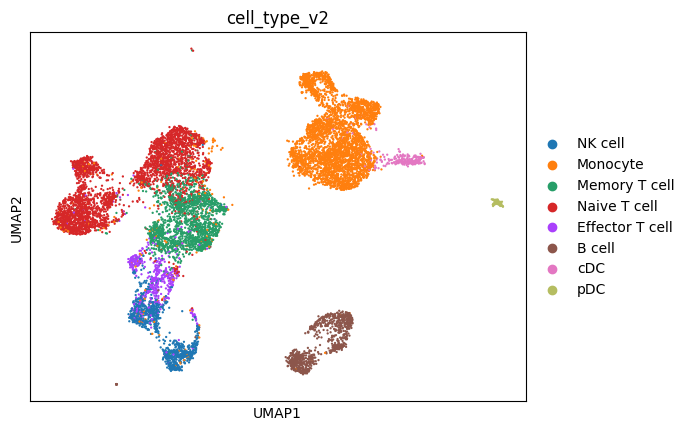

In [24]:
sc.pl.umap(mdata["atac"], color="cell_type_v2")

## Prepare Sequence Training Data

Transform the ATAC-seq peaks into training data for sequence modeling:

1. **Extract peak regions**: Define 256bp windows around accessibility peaks
2. **Retrieve DNA sequences**: Get reference genome sequences for each peak
3. **Create sequence-accessibility pairs**: Link DNA sequence with observed chromatin accessibility

This creates the fundamental training data pairing genomic sequence with regulatory activity.

In [25]:
cn.pp.add_peaks(mdata, mod_name='atac', peak_len=256)
cn.pp.add_dna_sequence(mdata, ref_fasta='../../../../data/refdata-gex-GRCh38-2020-A/fasta/genome.fa')

Fetching sequences: 100%|██████████| 115584/115584 [00:00<00:00, 278653.84it/s]



## Calculate Aggregated Accessibility Scores

Compute total accessibility for each genomic region by summing counts across all PBMC cells, then apply log1p transformation for normalized distribution. This aggregation captures the overall regulatory potential of each sequence while maintaining signal from all cell types.

In [26]:
df_seq = mdata['atac'].uns['peaks']
df_true = mdata['atac'].layers['counts'].todense().sum(axis=0)
df_seq['acc'] = np.array(df_true).flatten()
df_seq['acc'] = np.log1p(df_seq['acc'])

Examine the prepared sequence-accessibility training data:

In [27]:
df_seq.head()

,chr,start,end,summit,sequence,acc
chr1-817094-817594,chr1,817216,817472,817344,TGAGAGAAACTATTTGCAAACTATGCATCTGACAAAGGCCTAATAT...,7.178545
chr1-821831-822331,chr1,821953,822209,822081,TACCCTGTCTACACTACCTACCTGCCCAGCAGATCCACCCTGTCTT...,5.645447
chr1-826616-827116,chr1,826738,826994,826866,TTGTTCAAATTCCTCAGACCCATCCACTTCCCATCTAAACTTCCCT...,6.137727
chr1-827302-827802,chr1,827424,827680,827552,ACGCCGCAGGGAGGGGACTGCGTGGCTGGGTTTGGCCACAAAAAGC...,8.764834
chr1-842067-842567,chr1,842189,842445,842317,GAAGCGCACGCACCAGCCGTTCCACCCACCGAAGTTGTTTGGTCCC...,5.153292


## Create Chromosome-Based Data Split

Split the training data by chromosome to ensure robust evaluation without sequence similarity leakage. This approach:

- **Prevents overfitting**: No sequence overlap between training and validation
- **Tests generalization**: Model must predict accessibility on completely unseen chromosomes  
- **Mimics real applications**: Evaluates performance on novel genomic regions

**Training chromosomes (80%)**: Used for model learning  
**Validation chromosomes (20%)**: Used for performance assessment

In [28]:
# split data into training and validation sets by chromosome
chromosomes = df_seq['chr'].unique().tolist()
np.random.seed(42)
np.random.shuffle(chromosomes)
split_idx = int(len(chromosomes) * 0.8)
train_chromosomes = chromosomes[:split_idx]
valid_chromosomes = chromosomes[split_idx:]

print("Training chromosomes:", train_chromosomes)
print("Validation chromosomes:", valid_chromosomes)

Training chromosomes: ['chr16', 'chr10', 'chr1', 'chr9', 'chr18', 'chr13', 'chr2', 'chr14', 'chr6', 'chr3', 'chr12', 'chr21', 'chr4', 'chr5', 'chr19', 'chr17', 'chr22', 'chrX']
Validation chromosomes: ['chr8', 'chr11', 'chr15', 'chr20', 'chr7']


Extract essential columns (DNA sequence and accessibility score) for model training:

In [29]:
df_train = df_seq[df_seq['chr'].isin(train_chromosomes)]
df_valid = df_seq[df_seq['chr'].isin(valid_chromosomes)]

df_train = df_train[['sequence', 'acc']].reset_index(drop=True)
df_valid = df_valid[['sequence', 'acc']].reset_index(drop=True)

## Examine Data Distributions

Visualize the distribution of accessibility scores to ensure balanced and well-distributed training data across both datasets.

### Training Set Distribution:

<Axes: xlabel='acc', ylabel='Count'>

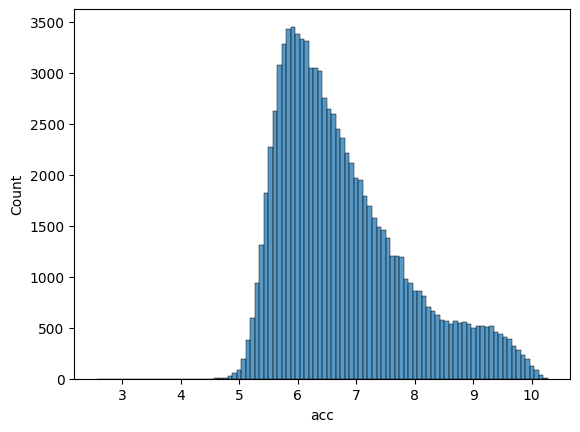

In [30]:
sns.histplot(df_train['acc'], bins=100)

### Validation Set Distribution:

<Axes: xlabel='acc', ylabel='Count'>

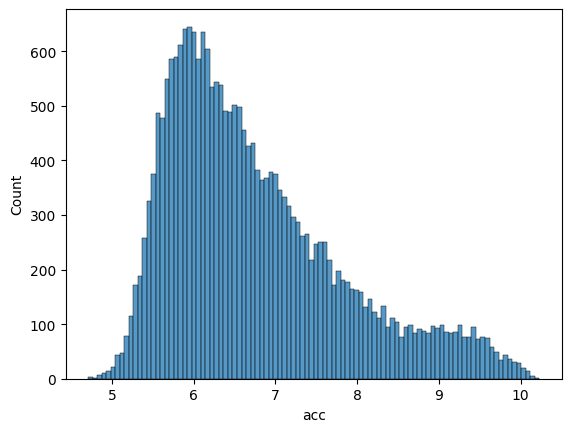

In [31]:
sns.histplot(df_valid['acc'], bins=100)

## Initialize Seq2Acc Model

Create a sequence-to-accessibility model with optimized architecture:

- **peak_len=256**: Input DNA sequences of 256 base pairs
- **dropout_rate=0.25**: Regularization to prevent overfitting across diverse cell types

The Seq2Acc model uses convolutional neural networks to learn sequence motifs and patterns that predict chromatin accessibility across the immune system.

In [32]:
model = cn.pd.model.Seq2Acc(peak_len=256, dropout_rate=0.25)

## Train the Sequence Encoder

Train the model to learn sequence-to-accessibility relationships using optimized hyperparameters:

- **max_epochs=100**: Maximum training iterations with early stopping
- **batch_size=512**: Large batches for stable gradient estimates across diverse PBMC sequences  
- **weight_decay=1e-04**: L2 regularization to prevent overfitting
- **lr=3e-04**: Learning rate optimized for convergence across immune cell types

The model learns to recognize DNA sequence patterns (transcription factor binding sites, GC content, repeats) that predict chromatin accessibility across the diverse PBMC cellular landscape.

In [ ]:
model.train(df_train=df_train, df_valid=df_valid, max_epochs=100,
            batch_size=512, weight_decay=1e-04, lr=3e-04)

2025-11-28 17:36:50 INFO     Creating dataloaders for training and validation
2025-11-28 17:37:03 INFO     Training peaks: 92596, Validation peaks: 22988
2025-11-28 17:37:03 INFO     Training peaks: 92596, Validation peaks: 22988
2025-11-28 17:37:04 INFO     Start training
2025-11-28 17:37:04 INFO     Start training
2025-11-28 17:37:07 INFO     Epoch 0:, Train: 38.9866, Valid: 23.8903, Best: 23.8903
2025-11-28 17:37:07 INFO     Epoch 0:, Train: 38.9866, Valid: 23.8903, Best: 23.8903
2025-11-28 17:37:10 INFO     Epoch 1:, Train: 10.7385, Valid: 1.6611, Best: 1.6611
2025-11-28 17:37:10 INFO     Epoch 1:, Train: 10.7385, Valid: 1.6611, Best: 1.6611
2025-11-28 17:37:13 INFO     Epoch 2:, Train: 2.7903, Valid: 0.8397, Best: 0.8397
2025-11-28 17:37:13 INFO     Epoch 2:, Train: 2.7903, Valid: 0.8397, Best: 0.8397
2025-11-28 17:37:16 INFO     Epoch 3:, Train: 2.4305, Valid: 0.8178, Best: 0.8178
2025-11-28 17:37:16 INFO     Epoch 3:, Train: 2.4305, Valid: 0.8178, Best: 0.8178
2025-11-28 17:37:2

## Save Pretrained Encoder Weights

Save the trained sequence encoder for transfer learning in downstream Cell2Net applications. The pretrained weights capture fundamental sequence-to-accessibility relationships learned from PBMC diversity.

In [34]:
model.save_module('./pretrained_seq2acc.pth')

2025-11-28 17:39:08 INFO     Trained module saved to ./pretrained_seq2acc.pth


## Load Best Model for Evaluation

Reload the optimal model weights (selected based on validation performance) for final evaluation and visualization.

In [35]:
# load best model weights
pretrained_state_dict = torch.load('./pretrained_seq2acc.pth')
model.module.seq_encoder.load_state_dict(pretrained_state_dict)

<All keys matched successfully>

## Generate Model Predictions

Apply the trained model to predict accessibility scores for both training and validation datasets.

In [36]:
df_train['pred_acc'] = model.predict(df_train)
df_valid['pred_acc'] = model.predict(df_valid)

Predicting: 100%|██████████| 724/724 [00:02<00:00, 255.70it/s]

Predicting: 100%|██████████| 180/180 [00:00<00:00, 180.13it/s]


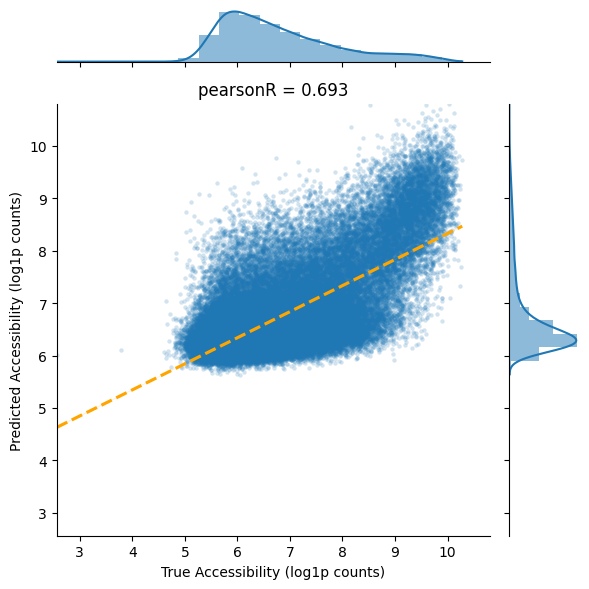

In [ ]:
pearsonR, pv = stats.pearsonr(df_train['acc'], df_train['pred_acc'])

ax = sns.jointplot(
    data=df_train,
    x="acc",
    y="pred_acc",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.2, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, 
              line_kws={"color": "orange", 'linestyle':'dashed'})
_min = np.min((np.min(df_train['acc'].values), np.min(df_train['pred_acc'].values)))
_max = np.max((np.max(df_train['acc'].values), np.max(df_train['pred_acc'].values)))

# set axis-x and axis-y the same scale
plt.xlim(_min, _max)
plt.ylim(_min, _max)
plt.title(f'pearsonR = {pearsonR:.3f}')
plt.xlabel('True Accessibility (log1p counts)')
plt.ylabel('Predicted Accessibility (log1p counts)')
plt.tight_layout()

## Evaluate Model Performance

### Training Set Performance

Assess how well the model learned sequence-to-accessibility relationships on training data. The Pearson correlation measures the linear relationship between predicted and true accessibility values.

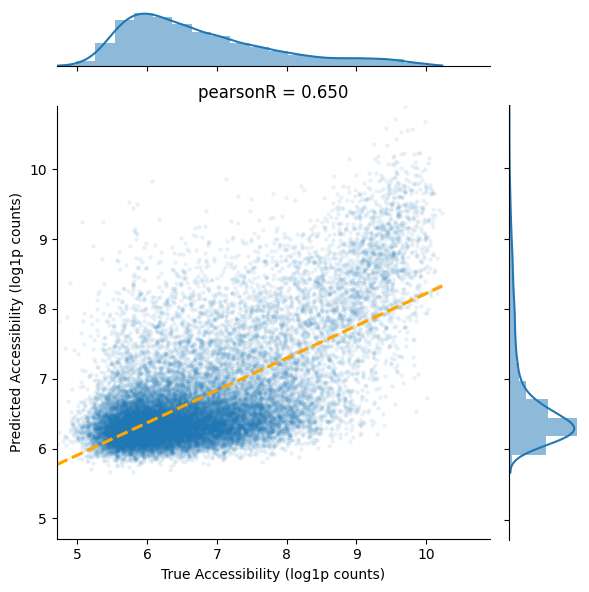

In [ ]:
pearsonR, pv = stats.pearsonr(df_valid['acc'], df_valid['pred_acc'])

ax = sns.jointplot(
    data=df_valid,
    x="acc",
    y="pred_acc",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, 
              line_kws={"color": "orange", 'linestyle':'dashed'})

_min = np.min((np.min(df_valid['acc'].values), np.min(df_valid['pred_acc'].values)))
_max = np.max((np.max(df_valid['acc'].values), np.max(df_valid['pred_acc'].values)))

# set axis-x and axis-y the same scale
plt.xlim(_min, _max)
plt.ylim(_min, _max)
plt.title(f'pearsonR = {pearsonR:.3f}')
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('True Accessibility (log1p counts)')
plt.ylabel('Predicted Accessibility (log1p counts)')
plt.tight_layout()

### Validation Set Performance

Evaluate model generalization on completely unseen chromosomes. This tests the model's ability to predict accessibility for novel genomic regions across the PBMC immune system diversity.

## Summary and Next Steps

### ✅ Accomplishments:

1. **Loaded PBMC multiome data** representing immune system cellular diversity
2. **Prepared sequence-accessibility training pairs** from 256bp genomic windows
3. **Trained a sequence encoder** to predict chromatin accessibility from DNA sequence
4. **Evaluated performance** on held-out chromosomes demonstrating generalization
5. **Saved pretrained weights** for transfer learning in downstream Cell2Net applications

### 🎯 Key Results:
- Successfully learned sequence-to-accessibility relationships across immune cell types
- Demonstrated generalization to unseen genomic regions
- Created a reusable sequence encoder capturing PBMC regulatory grammar


The trained encoder has learned fundamental sequence patterns that drive chromatin accessibility across.
It serves as a powerful foundation for downstream Cell2Net applications focused on immune system regulation and function.